In [49]:
import matlab.engine
import os
import matplotlib.pyplot as plt
from functools import lru_cache
from cache_spectrum import evaluate_with_cache

path = 'C:/Users/alexey/YandexDisk/Projects/metasurface_spectral_filters/signal_processing_PCM_metasurfaces/V10_2025/results/new_antennas/'


eng = matlab.engine.start_matlab()
eng.addpath(path, nargout=0)
# output1, ouput2, output3 = eng.run(f"{path}cmaes_exp_fit",0.090, nargout=3)
# y = eng.workspace[('x')]

h = float(0.12546719897087202)

output2, output3 = eng.r_t_calc_multi_param(1.7, 4.0,50, h, 1.1286971151594472, 0.9425861937065012, 0.22694812020681404, nargout=2)



# import numpy as np
# 
# arr = np.array(output2)
# plt.plot(arr[0])



In [51]:
eng.quit()

In [112]:
from functools import lru_cache
import numpy as np
import time

# print("Запуск MATLAB engine...")
# eng = matlab.engine.start_matlab()
# eng.addpath(eng.pwd(), nargout=0)
# eng.addpath(path, nargout=0)


def get_keys(x: np.ndarray, cache_precision = 4) -> tuple:
    return tuple(np.round(v, cache_precision) for v in x )
    
@lru_cache(maxsize=None)
def evaluate(x: tuple):
    h = float(x[0])
    t = float(x[1])
    output2, output3 = eng.r_t_calc_multi_param(1.7, 4.0,50, h, t, 0.9425861937065012, 0.22694812020681404, nargout=2)
    return output2, output3

start = time.perf_counter()
x = (0.081,1.12)
evaluate(x)
end = time.perf_counter()
print(f"Time taken: {end - start:.6f} seconds")
start = time.perf_counter()
x = (0.081,1.12)
evaluate(x)
end = time.perf_counter()
print(f"Time taken: {end - start:.6f} seconds")


# start = time.perf_counter()
# evaluate(y)
# end = time.perf_counter()
# print(f"Time taken: {end - start:.6f} seconds")
# start = time.perf_counter()

Time taken: 22.667873 seconds
Time taken: 0.000043 seconds


In [111]:
output2, output3 = eng.r_t_calc_multi_param(1.7, 4.0,50, 0.8, 1.12, 0.4425861937065012, 0.22694812020681404, nargout=2)


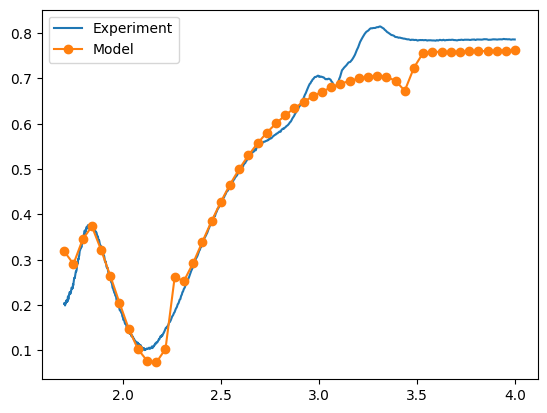

In [3]:
import numpy as np 
import data_processing as dp
wl_min = 1.7
wl_max = 4.0
data = np.genfromtxt('./LIPPS_sio2_polarized.csv', delimiter=',')
wl, lipss = dp.crop_wl(wl_min, wl_max, data, 6)


plt.plot(wl,lipss/100)
wl_model = np.linspace(1.7, 4.0, 50)
arr = np.array(output2)
plt.plot(wl_model, arr[0], marker = 'o')
plt.legend(['Experiment', 'Model'])
# arr = np.array(output3)
# plt.plot(arr[0])

In [4]:
parameters_config = [
    ("h_cross",   0.09,  0.01,  0.20),  
    ("Px",        1,  0.50,  1.50),   
    ("Wy",       1,  0.50,  1.50),
    ("Gst_thickness",       0.23,  0.205,  0.4),
    # Добавляй новые параметры сюда по аналогии
]

initial_mean = np.array([p[1] for p in parameters_config])
lower_bounds = np.array([p[2] for p in parameters_config])
upper_bounds = np.array([p[3] for p in parameters_config])
bounds = np.stack((lower_bounds, upper_bounds)).T
individual_sigmas = 0.2 * (upper_bounds - lower_bounds)
print(individual_sigmas)


[0.038 0.2   0.2   0.039]


IndexError: list index out of range

In [13]:
from functools import lru_cache 
def get_cache_key(x: np.ndarray, CACHE_PRECISION) -> tuple:
    return tuple(round(float(v), CACHE_PRECISION) for v in x)

def get_cache_key(x: np.ndarray, eng) -> tuple:
    


CACHE_PRECISION = 3

values = np.array([0.44245, 0.23232, 0.48483, 12.233])

print(get_cache_key(values, CACHE_PRECISION))

IndentationError: expected an indented block after function definition on line 5 (2160710314.py, line 9)

{'hits': 1, 'misses': 0}


In [ ]:
import numpy as np
import matlab.engine
import h5py
from cmaes import CMA
from functools import lru_cache

from data_processing import (
    load_experimental_curve,
    calc_mae_model_experimental
    calc_rmse_model_experimental
)


# ===============================
# НАСТРОЙКИ КОНСТАНТ
# ===============================
WL_MIN = 1.7
WL_MAX = 4.0
N_wl_points = 100
wl_model = np.linspace(WL_MIN, WL_MAX, N_wl_points)
EXP_FILE = './LIPPS_sio2_polarized.csv'
EXP_COL = 6
path = 'C:/Users/alexey/YandexDisk/Projects/metasurface_spectral_filters/signal_processing_PCM_metasurfaces/V10_2025/results/new_antennas/'
filename_results = 'optimization_results_4params_PxWyfixed.h5'


from functools import lru_cache

from functools import lru_cache
import numpy as np

def create_evaluator(eng, cache_precision: int = 6, max_cache_size: int | None = None):
    """
    Создаёт и возвращает функцию evaluate_with_cache с привязанным eng и настройками кэша.

    Параметры:
        eng: запущенный matlab.engine объект
        cache_precision: количество знаков для округления параметров
        max_cache_size: максимальный размер кэша

    Возвращает:
        функцию evaluate_with_cache(x: np.ndarray) -> float
    """

    @lru_cache(maxsize=max_cache_size)
    def _cached_simulate(params_tuple: tuple) -> float:
        h_cross, Px, Wy, Gst_thickness = params_tuple

        try:
            signal_model_matlab, _ = eng.r_t_calc_multi_param(
                WL_MIN, WL_MAX,
                float(h_cross), float(Px), float(Wy), float(Gst_thickness),
                nargout=2
            )
            signal_model = np.array(signal_model_matlab).flatten()
            value = calc_rmse_model_experimental(wl_exp, wl_model, signal_exp, signal_model)
        except Exception as e:
            print(f"Ошибка MATLAB для {params_tuple}: {e}")
            value = np.inf

        return value

    def evaluate_with_cache(x: np.ndarray) -> float:
        key_tuple = tuple(round(float(v), cache_precision) for v in x)
        return _cached_simulate(key_tuple)

    # Добавляем удобный доступ к статистике
    evaluate_with_cache.cache_info = _cached_simulate.cache_info
    evaluate_with_cache.cache_clear = _cached_simulate.cache_clear

    return evaluate_with_cache


# -----------------------------
# ОПРЕДЕЛЕНИЕ ПАРАМЕТРОВ
# -----------------------------
parameters_config = [
    ("h_cross",       0.09,  0.01,  0.20),   # толщина креста GST
    ("Px",            1.00,  0.50,  1.50),   # период по x
    ("Wy",            1.00,  0.50,  1.50),   # ширина плеча креста
    ("Gst_thickness", 0.23,  0.205, 0.40),   # общая толщина GST-слоя (подложка + крест)
]

n_dim = len(parameters_config)

# Формируем массивы для CMA-ES
initial_mean = np.array([p[1] for p in parameters_config])
lower_bounds = np.array([p[2] for p in parameters_config])
upper_bounds = np.array([p[3] for p in parameters_config])
bounds = np.stack((lower_bounds, upper_bounds)).T  # shape (n_dim, 2)

# Индивидуальные sigma: 20% от ширины диапазона каждого параметра
individual_sigmas = 0.2 * (upper_bounds - lower_bounds)

param_names = [p[0] for p in parameters_config]

# Параметры CMA-ES
POPULATION_SIZE = max(12, 4 + int(3 * np.log(n_dim)))  # ~15 для 4 параметров
N_ITER = 50
SEED = 42

# ===============================
# ЭКСПЕРИМЕНТАЛЬНЫЕ ДАННЫЕ
# ===============================
wl_exp, signal_exp = load_experimental_curve(
    wl_min=WL_MIN, wl_max=WL_MAX,
    experimental_file_path=EXP_FILE,
    col_index=EXP_COL
)
signal_exp /= 100.0



# ===============================
# CMA-ES ОПТИМИЗАТОР
# ===============================
optimizer = CMA(
    mean=initial_mean,
    sigma=0.2,                # массив индивидуальных sigma
    bounds=bounds,
    seed=SEED,
    population_size=POPULATION_SIZE
)
# После запуска MATLAB engine
print("Запуск MATLAB engine...")
eng = matlab.engine.start_matlab()
eng.addpath(eng.pwd(), nargout=0)
eng.addpath(path, nargout=0)

# Создаём кэшированную функцию оценки

evaluate = create_evaluator(
    eng=eng,
    cache_precision=4,      # сколько знаков после запятой считать "одинаковыми"
    max_cache_size=None     # None = без ограничения, или например 10000
)

# Теперь в цикле оптимизации:
for iteration in range(N_ITER):
    solutions = []
    for _ in range(optimizer.population_size):
        x = optimizer.ask()
        value = evaluate(x)               # ← чистый вызов, без eng
        solutions.append((x.copy(), value))

    optimizer.tell(solutions)

    best_x, best_loss = min(solutions, key=lambda t: t[1])
    best_params = dict(zip(param_names, best_x))

    print(f"Iter {iteration+1:02d}/{N_ITER} | best MAE = {best_loss:.6e} | params = {best_params}")

    # Статистика кэша
    info = evaluate.cache_info()
    hit_rate = 100 * info.hits / (info.hits + info.misses) if (info.hits + info.misses) > 0 else 0
    print(f"   Кэш: {info.currsize} записей | hits: {info.hits} | hit rate: {hit_rate:.1f}%")
# ===============================
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В HDF5
# ===============================

Запуск MATLAB engine...
Iter 01/50 | best MAE = 6.207871e-03 | params = {'h_cross': np.float64(0.045307442934829814), 'Px': np.float64(1.1428000988184184), 'Wy': np.float64(1.094647524914709), 'Gst_thickness': np.float64(0.21543421746862546)}
   Кэш: 12 записей | hits: 0 | hit rate: 0.0%
Ошибка MATLAB для (0.0279, 0.9019, 0.7934, 0.2876): cannot unpack non-iterable NoneType object
